In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.style.use("dark_background")

Text(0, 0.5, 'Principal Component Petal')

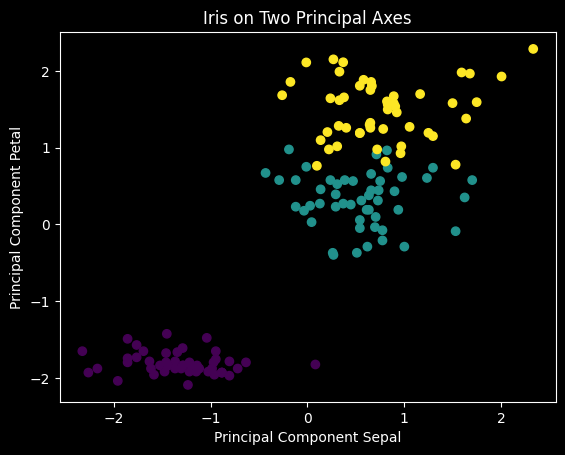

In [2]:
df = pd.read_csv("data/002-iris.csv")
df = df.set_index("Id")

X_raw = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].to_numpy()
Y_raw = df[["Species"]].to_numpy()

s_scaler = StandardScaler()
s_scaler.fit(X_raw)

X_raw = s_scaler.transform(X_raw)

pca = PCA(n_components=1)
pcs = pca.fit_transform(X_raw[:, :2])
pcp = pca.fit_transform(X_raw[:, 2:])

X_raw = np.column_stack((pcs, pcp))
cats, Y_raw = np.unique(Y_raw, return_inverse=True)

X, X_test, Y, Y_test = train_test_split(X_raw, Y_raw, test_size=0.5, random_state=67)

plt.scatter(X_raw[:, 0], X_raw[:, 1], c=Y_raw[:, 0])
plt.title("Iris on Two Principal Axes")
plt.xlabel("Principal Component Sepal")
plt.ylabel("Principal Component Petal")

/home/loselen/projects/ai-projects/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Text(0, 0.5, 'Principal Component Petal')

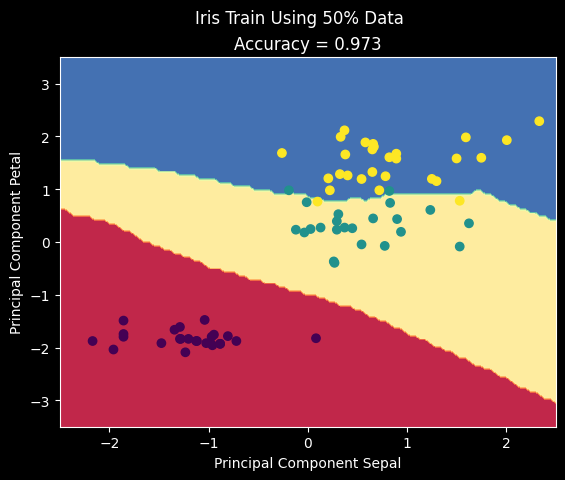

In [3]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X, Y)
Y_pred = knn.predict(X_test)

xx, yy = np.meshgrid(
    np.linspace(-2.5, 2.5, 100),
    np.linspace(-3.5, 3.5, 100)
)

grid_inputs = np.column_stack((xx.flatten(), yy.flatten()))
Z = knn.predict(grid_inputs)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap="Spectral")
plt.scatter(X[:, 0], X[:, 1], c=Y[:, 0], cmap="viridis")
plt.suptitle("Iris Train Using 50% Data")
plt.title(f"Accuracy = {accuracy_score(Y_test, Y_pred):.3f}")
plt.xlabel("Principal Component Sepal")
plt.ylabel("Principal Component Petal")

Text(0, 0.5, 'Principal Component Petal')

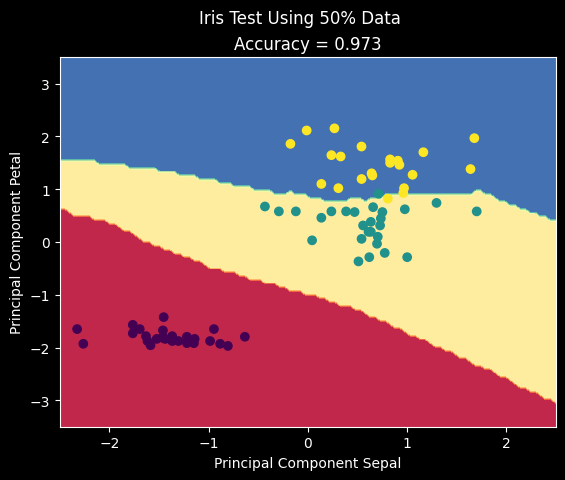

In [4]:
Y_pred = knn.predict(X_test)

plt.contourf(xx, yy, Z, cmap="Spectral")
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test[:, 0])
plt.suptitle("Iris Test Using 50% Data")
plt.title(f"Accuracy = {accuracy_score(Y_test, Y_pred):.3f}")
plt.xlabel("Principal Component Sepal")
plt.ylabel("Principal Component Petal")